In [44]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("../data/silver/cleaned_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits
0,5,11.051381,0.230652,Organic,3.890460,3
1,4,3.429316,0.391001,Social,8.478174,0
2,4,1.621052,0.397986,Organic,9.636170,2
3,5,3.629279,0.180458,Organic,2.071925,3
4,5,4.235843,0.291541,Paid,1.960654,5


In [46]:
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500
std,2.183903,3.104518,0.159781,2.887422,1.432852
min,0.000000,0.003613,0.007868,0.068515,0.000000
25%,3.000000,0.815828,0.161986,1.935037,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000


In [47]:
#Average time spend on per page by user 
df["Avg Time Per Page"] = df["Time on Page"] / df["Page Views"]

In [48]:
# Step 1: Total Time
df['Timespend'] = ((df['Session Duration']+ df['Time on Page']))


In [49]:
df.isnull().sum()

Page Views           0
Session Duration     0
Bounce Rate          0
Traffic Source       0
Time on Page         0
Previous Visits      0
Avg Time Per Page    0
Timespend            0
dtype: int64

In [50]:
df.describe()

c:\NUMPY_YT\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract



,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Avg Time Per Page,Timespend
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,inf,7.049484
std,2.183903,3.104518,0.159781,2.887422,1.432852,NaN,4.210048
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.006852,0.106521
25%,3.000000,0.815828,0.161986,1.935037,1.000000,0.392024,3.926401
50%,5.000000,1.993983,0.266375,3.315316,2.000000,0.713874,6.198578
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.311601,9.303733
max,14.000000,20.290516,0.844939,24.796182,9.000000,inf,34.447424


In [51]:
# Step 2: Return target using last 1 month previous visits and drop Previous vists column due to data leakage 
df["Return"] = (df["Previous Visits"] > 1).astype(int)
df = df.drop(columns=["Previous Visits"])

In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.corr(method='spearman')

,Page Views,Session Duration,Bounce Rate,Time on Page,Avg Time Per Page,Timespend,Return
Page Views,1.000000,-0.007402,0.027002,0.020028,-0.493926,-0.003020,0.033935
Session Duration,-0.007402,1.000000,-0.002325,0.004357,0.011706,0.649617,-0.013405
Bounce Rate,0.027002,-0.002325,1.000000,0.038775,0.009929,0.023805,0.008986
Time on Page,0.020028,0.004357,0.038775,1.000000,0.829656,0.689221,-0.030591
Avg Time Per Page,-0.493926,0.011706,0.009929,0.829656,1.000000,0.579688,-0.045704
Timespend,-0.003020,0.649617,0.023805,0.689221,0.579688,1.000000,-0.027060
Return,0.033935,-0.013405,0.008986,-0.030591,-0.045704,-0.027060,1.000000


In [53]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
1    58.95
0    41.05
Name: proportion, dtype: float64


In [54]:
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Avg Time Per Page,Timespend,Return
0,5,11.051381,0.230652,Organic,3.890460,0.778092,14.941841,1
1,4,3.429316,0.391001,Social,8.478174,2.119544,11.907490,0
2,4,1.621052,0.397986,Organic,9.636170,2.409042,11.257222,1
3,5,3.629279,0.180458,Organic,2.071925,0.414385,5.701204,1
4,5,4.235843,0.291541,Paid,1.960654,0.392131,6.196497,1


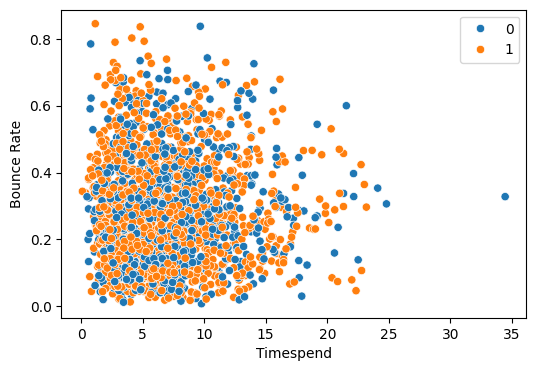

In [55]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Timespend',y='Bounce Rate', hue = 'Return', data= df)
plt.legend()
plt.show()

In [56]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Timespend',
    y='Page Views',
    z='Bounce Rate',
    color='Return'   # return vs not return
)

fig.show()

### after seeing the data --- data overlaped

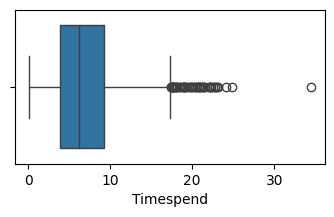

In [57]:
#for single column boxplot 
plt.figure(figsize=(4,2))
sns.boxplot(x=df['Timespend'])
plt.show()

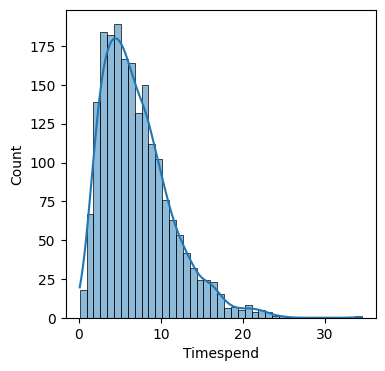

In [58]:
plt.figure(figsize=(4,4))
sns.histplot(df['Timespend'], kde=True)
plt.show()

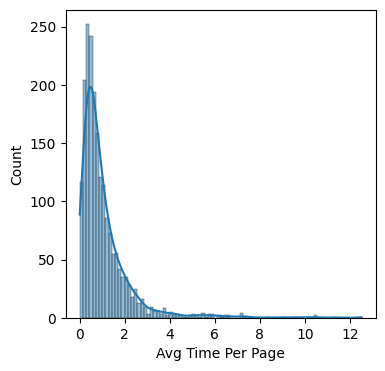

In [59]:
plt.figure(figsize=(4,4))
sns.histplot(df['Avg Time Per Page'], kde=True)
plt.show()

In [25]:
#gold data stores parquet format in gold layer---because parquet format fast , take less size and big data frindly  

#pip install pyarrow---needded environment
 
#df.to_parquet("data/gold/feature_data.parquet", index=False)

In [60]:
df.to_csv("../data/gold/feature_data.csv", index=False)